# Leave-out-half interpolation error analysis

Loads **`data/fe_nlte_new.zarr`**, builds a **decimated copy** of the grid (every second value dropped along Teff and log g), and uses that decimated grid for all interpolation. The original (full) grid provides **ground truth** at the held-out parameter points.

Everything below is built on this single test:

- **Reconstructed** = `interp_dec.get_weighted_batch(...)` on the decimated grid.
- **Truth** = the stored catalogue spectrum at the same parameter point in the original grid.
- **% residual** = `100 × (reconstructed − truth) / max(|reconstructed|, |truth|, ε)`.

`LazyZarrInterpolator` itself is unchanged — see [`lazy_zarr_interpolator.py`](../src/spice/spectrum/lazy_zarr_interpolator.py) for `_compute_brackets`, `make_corners`, `SparseGridIndex.lookup`, and `get_weighted_batch`.


In [1]:
import zarr
o = zarr.open_group('/home/100/mj8805/gy89/runs/fe-nlte-new-dense/outputs/zarr/regular_synthesized_spectra.zarr')
o.tree()

/
├── continuum (573221, 2001) float32
├── flux (573221, 2001) float32
├── global_index (573221,) int64
├── model_id (573221,) uint64
├── param_names (11,) <U32
├── params (573221, 11) float32
├── physics_hash (1,) <U72
├── provenance
│   ├── atmosphere_manifest.json (1,) StringDType()
│   ├── canonical_config.yaml (1,) StringDType()
│   ├── environment.txt (1,) StringDType()
│   ├── linelist_manifest.json (1,) StringDType()
│   ├── software_manifest.json (1,) StringDType()
│   └── synthesis_config.yaml (1,) StringDType()
├── schema_version (1,) <U16
└── wavelength (2001,) float32

In [2]:
import numpy as np
# Show the grid's parameter coverage: min, max, and number of unique steps for each parameter in the grid.

param_names = o['param_names'][:]
params = o['params'][:]

print("Parameter coverage in zarr grid:")
for i, name in enumerate(param_names):
    col = params[:, i]
    unique = np.unique(col)
    print(f"  {name}: min={unique.min():.5g}, max={unique.max():.5g}, step={(unique.max()-unique.min())/len(unique)}")

Parameter coverage in zarr grid:
  teff: min=4000, max=8000, step=97.56097412109375
  logg: min=1, max=5, step=0.09756097197532654
  [Fe/H]: min=-2.5, max=0.5, step=0.09677419066429138
  vmicro: min=0, max=0, step=0.0
  [a/Fe]: min=0, max=0, step=0.0
  [C/Fe]: min=0, max=0, step=0.0
  [N/Fe]: min=0, max=0, step=0.0
  [O/Fe]: min=0, max=0, step=0.0
  [r/Fe]: min=0, max=0, step=0.0
  [s/Fe]: min=0, max=0, step=0.0
  mu: min=0.010018, max=1, step=0.09899820387363434


In [3]:
import os
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for _p in (_here, _here.parent):
    if (_p / "src" / "spice").is_dir():
        sys.path.insert(0, str(_p / "src"))
        break

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from spice.spectrum.lazy_zarr_interpolator import (
    LazyZarrInterpolator,
    _compute_brackets,
    make_corners,
)


## Load `fe_nlte_new.zarr`

The store under `data/` is opened read-only. All numeric columns except `row_idx` become grid axes for full-dimensional multilinear interpolation; the **full** interpolator below is built only so we can read the original arrays and use them as truth.


In [4]:
# _repo = _here if (_here / "data" / "fe_nlte_new.zarr").is_dir() else _here.parent
store_path = Path('/home/100/mj8805/gy89/runs/fe-nlte-new-dense/outputs/zarr/regular_synthesized_spectra.zarr')
_index = store_path / "index.parquet"
if not _index.is_file():
    raise FileNotFoundError(f"Expected {_index}")

_df = pd.read_parquet(_index)
param_cols = [c for c in _df.columns if c != "row_idx"]

grid_row_idx = {}
for _, r in _df.sort_values("row_idx").iterrows():
    key = tuple(float(r[c]) for c in param_cols)
    if key not in grid_row_idx:
        grid_row_idx[key] = int(r["row_idx"])
if len(grid_row_idx) < len(_df):
    print(
        f"Note: {len(_df)} index rows share keys with earlier rows; "
        f"{len(grid_row_idx)} unique parameter tuples kept (first row_idx per key)."
    )

_z = zarr.open_group(str(store_path), mode="r")
print("Store:", store_path.resolve())
print("flux shape:", _z["flux"].shape, "wavelength shape:", _z["wavelength"].shape)
print("Interpolation columns (all dimensions):", param_cols)
print(f"Unique parameter tuples (vertices for sparse index): {len(grid_row_idx)}")
print(f"Rows in index.parquet: {len(_df)}")


Note: 573221 index rows share keys with earlier rows; 521110 unique parameter tuples kept (first row_idx per key).
Store: /g/data/y89/mj8805/runs/fe-nlte-new-dense/outputs/zarr/regular_synthesized_spectra.zarr
flux shape: (573221, 2001) wavelength shape: (2001,)
Interpolation columns (all dimensions): ['teff', 'logg', '[Fe/H]', 'vmicro', '[a/Fe]', '[C/Fe]', '[N/Fe]', '[O/Fe]', '[r/Fe]', '[s/Fe]', 'mu']
Unique parameter tuples (vertices for sparse index): 521110
Rows in index.parquet: 573221


In [5]:
interp = LazyZarrInterpolator(
    str(store_path),
    params=param_cols,
    in_memory=False,
    sparse=True,
    accumulate_chunk_size=None,
)

COLS = list(interp.grid_index.columns)
axes_jax = interp.grid_index.axes
teff_axis = np.asarray(axes_jax[COLS.index("teff")])
logg_axis = np.asarray(axes_jax[COLS.index("logg")])

# Mid-grid reference for every non-(teff, log g) axis. Used only for 1D-slice plots.
FIXED = {}
for i, name in enumerate(COLS):
    u = np.asarray(axes_jax[i])
    FIXED[name] = float(u[len(u) // 2])


def build_query_vec(teff, logg):
    return jnp.array(
        [
            float(teff) if name == "teff" else float(logg) if name == "logg" else FIXED[name]
            for name in COLS
        ],
        dtype=jnp.float64,
    )


print("Full grid (used only for truth lookup):")
print(f"  axes: {COLS}, d = {len(COLS)}")
print(f"  Teff ({len(teff_axis)}): {teff_axis}")
print(f"  log g ({len(logg_axis)}): {logg_axis}")
print("  FIXED other axes (mid-grid):", {k: FIXED[k] for k in COLS if k not in ('teff', 'logg')})


Building sparse grid index...
Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 1.0 s
Full grid (used only for truth lookup):
  axes: ['teff', 'logg', '[Fe/H]', 'vmicro', '[a/Fe]', '[C/Fe]', '[N/Fe]', '[O/Fe]', '[r/Fe]', '[s/Fe]', 'mu'], d = 11
  Teff (41): [4000. 4100. 4200. 4300. 4400. 4500. 4600. 4700. 4800. 4900. 5000. 5100.
 5200. 5300. 5400. 5500. 5600. 5700. 5800. 5900. 6000. 6100. 6200. 6300.
 6400. 6500. 6600. 6700. 6800. 6900. 7000. 7100. 7200. 7300. 7400. 7500.
 7600. 7700. 7800. 7900. 8000.]
  log g (41): [1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7
 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5
 4.6 4.7 4.8 4.9 5. ]
  FIXED other axes (mid-grid): {'[Fe/H]': -1.0, 'vmicro': 0.0, '[a/Fe]': 0.0, '[C/Fe]': 0.0, '[N/Fe]': 0.0, '[O/Fe]': 0.0, '[r/Fe]': 0.0, '[s/Fe]': 0.0, 'mu': 0.5984969735145569}


## Decimated leave-out-half grid

Keep `axis[::2]` along **Teff** and **log g**; build a temporary zarr with only the kept catalogue rows; open a fresh `LazyZarrInterpolator` on it. Then reconstruct every held-out row (every parameter combination whose Teff or log g sits between the kept values) and record per-spectrum residuals.

The temp zarr is removed at the end of the notebook.


In [6]:
# Build decimated grid + run leave-out reconstruction once for the whole notebook.
import shutil
import tempfile
from tqdm import tqdm  # <-- added for progress bar

# masks on axis indices (avoids float-equality issues)
teff_idx_all = np.searchsorted(teff_axis, _df["teff"].to_numpy(dtype=np.float32))
logg_idx_all = np.searchsorted(logg_axis, _df["logg"].to_numpy(dtype=np.float32))
keep_teff_idx = np.arange(0, len(teff_axis), 2)
keep_logg_idx = np.arange(0, len(logg_axis), 2)
held_teff_idx = np.arange(1, len(teff_axis), 2)
held_logg_idx = np.arange(1, len(logg_axis), 2)
keep_mask = np.isin(teff_idx_all, keep_teff_idx) & np.isin(logg_idx_all, keep_logg_idx)
held_mask = np.isin(teff_idx_all, held_teff_idx) & np.isin(logg_idx_all, held_logg_idx)

keep_teff_vals = teff_axis[keep_teff_idx]
keep_logg_vals = logg_axis[keep_logg_idx]
held_teff_vals_axis = teff_axis[held_teff_idx]
held_logg_vals_axis = logg_axis[held_logg_idx]

print(f"kept (Teff, log g): {len(keep_teff_vals)} x {len(keep_logg_vals)};"
      f" held: {len(held_teff_vals_axis)} x {len(held_logg_vals_axis)}")
print(f"index rows kept: {int(keep_mask.sum())}, held: {int(held_mask.sum())}")

flux_full_np = np.asarray(interp.rowwise_data["flux"])
cont_full_np = np.asarray(interp.rowwise_data["continuum"])
wave_np = np.asarray(interp.static_data["wavelength"])

orig_kept_rowidx = _df.loc[keep_mask, "row_idx"].to_numpy(dtype=int)
new_flux = flux_full_np[orig_kept_rowidx]
new_cont = cont_full_np[orig_kept_rowidx]

tmp_dir = Path(tempfile.mkdtemp(prefix="spice_leave_out_half_"))
dec_path = tmp_dir / "decimated.zarr"
dec_group = zarr.open_group(str(dec_path), mode="w")
dec_group.create_array("wavelength", data=wave_np)
chunk_rows = min(64, new_flux.shape[0])
dec_group.create_array("flux", data=new_flux, chunks=(chunk_rows, new_flux.shape[1]))
dec_group.create_array("continuum", data=new_cont, chunks=(chunk_rows, new_cont.shape[1]))
new_index = _df.loc[keep_mask, param_cols].copy()
new_index.insert(0, "row_idx", np.arange(len(new_index), dtype=np.int32))
new_index.to_parquet(str(dec_path / "index.parquet"))
print(f"Decimated zarr written to {dec_path}")

interp_dec = LazyZarrInterpolator(
    str(dec_path),
    params=param_cols,
    in_memory=True,
    sparse=True,
    accumulate_chunk_size=8,
)
COLS_DEC = list(interp_dec.grid_index.columns)
axes_dec = interp_dec.grid_index.axes
flux_dec_np = np.asarray(interp_dec.rowwise_data["flux"])
new_index_for_lookup = pd.read_parquet(dec_path / "index.parquet")
grid_row_idx_dec = {
    tuple(float(row[c]) for c in param_cols): int(row["row_idx"])
    for _, row in new_index_for_lookup.iterrows()
}

held_df = _df.loc[held_mask].reset_index(drop=True)
held_queries = held_df[param_cols].to_numpy(dtype=np.float64)
held_truth = flux_full_np[held_df["row_idx"].to_numpy(dtype=int)].astype(np.float64)


def reconstruct_chunked(Q, chunk=256):
    out = np.empty((Q.shape[0], wave_np.shape[0]), dtype=np.float64)
    # Wrap tqdm for progress bar over total held-out spectra
    for i in tqdm(range(0, Q.shape[0], chunk), desc="Reconstructing", total=(Q.shape[0] + chunk - 1) // chunk):
        sl = slice(i, min(i + chunk, Q.shape[0]))
        out[sl] = np.asarray(
            interp_dec.get_weighted_batch(jnp.asarray(Q[sl], dtype=jnp.float64))["flux"]
        )
    return out


print(f"Reconstructing {len(held_queries)} held-out spectra ...")
held_pred = reconstruct_chunked(held_queries, chunk=64)
print("done")

denom_spec = np.maximum(np.maximum(np.abs(held_pred), np.abs(held_truth)), 1e-30)
pct_spec = 100.0 * (held_pred - held_truth) / denom_spec
rms_per_spec_pct = np.sqrt(np.mean(pct_spec ** 2, axis=1))
mean_per_spec_pct = np.mean(pct_spec, axis=1)
maxabs_per_spec = np.max(np.abs(pct_spec), axis=1)
order_rms = np.argsort(rms_per_spec_pct)
selections = {
    "worst": int(order_rms[-1]),
    "median": int(order_rms[len(order_rms) // 2]),
    "best": int(order_rms[0]),
}

print(
    "per-spectrum RMS % residual: "
    f"median = {np.median(rms_per_spec_pct):.3f}, "
    f"mean = {rms_per_spec_pct.mean():.3f}, "
    f"p95 = {np.percentile(rms_per_spec_pct, 95):.3f}, "
    f"max = {rms_per_spec_pct.max():.3f}"
)
print(f"max single-bin |%| anywhere: {maxabs_per_spec.max():.3f}")


kept (Teff, log g): 21 x 21; held: 20 x 20
index rows kept: 150381, held: 136400
Decimated zarr written to /jobfs/168654617.gadi-pbs/spice_leave_out_half_69z8wfr1/decimated.zarr
Building sparse grid index...
Sparse grid index ready.


/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/spice/spectrum/lazy_zarr_interpolator.py:584: UserWarning: Eager in_memory load requested for 2.41 GB of rowwise data, which exceeds the 2.15 GB threshold and may cause an out-of-memory crash. Consider in_memory='auto' or in_memory=False.
  warnings.warn(


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 2.4 s
Reconstructing 136400 held-out spectra ...


Reconstructing: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2132/2132 [13:27<00:00,  2.64it/s]


done
per-spectrum RMS % residual: median = 8.619, mean = 9.396, p95 = 22.328, max = 78.049
max single-bin |%| anywhere: 99.392


## Corner coordinates and weights (decimated interpolator)

For each axis, `_compute_brackets` returns `(lo, hi, t)` with `t` the fraction between `axes_dec[lo]` and `axes_dec[hi]`. Corners come from `make_corners(d)` exactly as in the sparse multilinear path. The example query is the **worst** held-out row by RMS % so the corner layout is meaningful.


In [14]:
def corner_points_and_weights(axes, query_vec, col_names):
    # Multilinear corners in full parameter space (same rule as the interpolator).
    q = jnp.asarray(query_vec, dtype=jnp.float64)
    brackets = _compute_brackets(axes, q)
    lo = brackets[:, 0].astype(jnp.int32)
    hi = brackets[:, 1].astype(jnp.int32)
    t = brackets[:, 2]
    d = len(axes)
    corners = make_corners(d)
    indices = jnp.where(corners == 0, lo, hi)
    weights = jnp.where(corners == 0, 1.0 - t, t)
    weights = jnp.prod(weights, axis=1)
    pts = []
    for k in range(indices.shape[0]):
        idx_tuple = tuple(int(indices[k, i]) for i in range(d))
        dct = {col_names[i]: float(axes[i][idx_tuple[i]]) for i in range(d)}
        dct["idx"] = idx_tuple
        dct["weight"] = float(weights[k])
        pts.append(dct)
    return brackets, pts


idx = selections["worst"]
qv = jnp.asarray(held_queries[idx], dtype=jnp.float64)
brackets_ex, corners_ex = corner_points_and_weights(axes_dec, qv, COLS_DEC)
rm = held_df.iloc[idx]
print(f"worst held-out row: Teff={float(rm['teff']):.0f}, log g={float(rm['logg']):.3f}, "
      f"[Fe/H]={float(rm['[Fe/H]']):.2f}, mu={float(rm['mu']):.3f}, "
      f"RMS %={rms_per_spec_pct[idx]:.3f}")
print("brackets (decimated axes, per axis: lo, hi, t):")
print(np.asarray(brackets_ex))
print("Active corners (weight > 0):")
for c in corners_ex:
    if c["weight"] > 0:
        print(f"  idx={c['idx']}  w={c['weight']:.4f}  teff={c['teff']:.0f}  logg={c['logg']:.3f}")


worst held-out row: Teff=5100, log g=2.700, [Fe/H]=-2.50, mu=1.000, RMS %=78.049
brackets (decimated axes, per axis: lo, hi, t):
[[5.        6.        0.5      ]
 [8.        9.        0.5000006]
 [0.        0.        0.       ]
 [0.        0.        0.       ]
 [0.        0.        0.       ]
 [0.        0.        0.       ]
 [0.        0.        0.       ]
 [0.        0.        0.       ]
 [0.        0.        0.       ]
 [0.        0.        0.       ]
 [9.        9.        0.       ]]
Active corners (weight > 0):
  idx=(5, 8, 0, 0, 0, 0, 0, 0, 0, 0, 9)  w=0.2500  teff=5000  logg=2.600
  idx=(5, 9, 0, 0, 0, 0, 0, 0, 0, 0, 9)  w=0.2500  teff=5000  logg=2.800
  idx=(6, 8, 0, 0, 0, 0, 0, 0, 0, 0, 9)  w=0.2500  teff=5200  logg=2.600
  idx=(6, 9, 0, 0, 0, 0, 0, 0, 0, 0, 9)  w=0.2500  teff=5200  logg=2.800


## Reconstruction error across the held-out grid

Histogram of per-spectrum RMS %, plus three heatmaps over held-out `(Teff, log g)` cells aggregating across every other parameter combination at the same thermal point:
- Mean **RMS %**
- Mean **signed %**
- **Max |%|** anywhere in any held spectrum at that cell


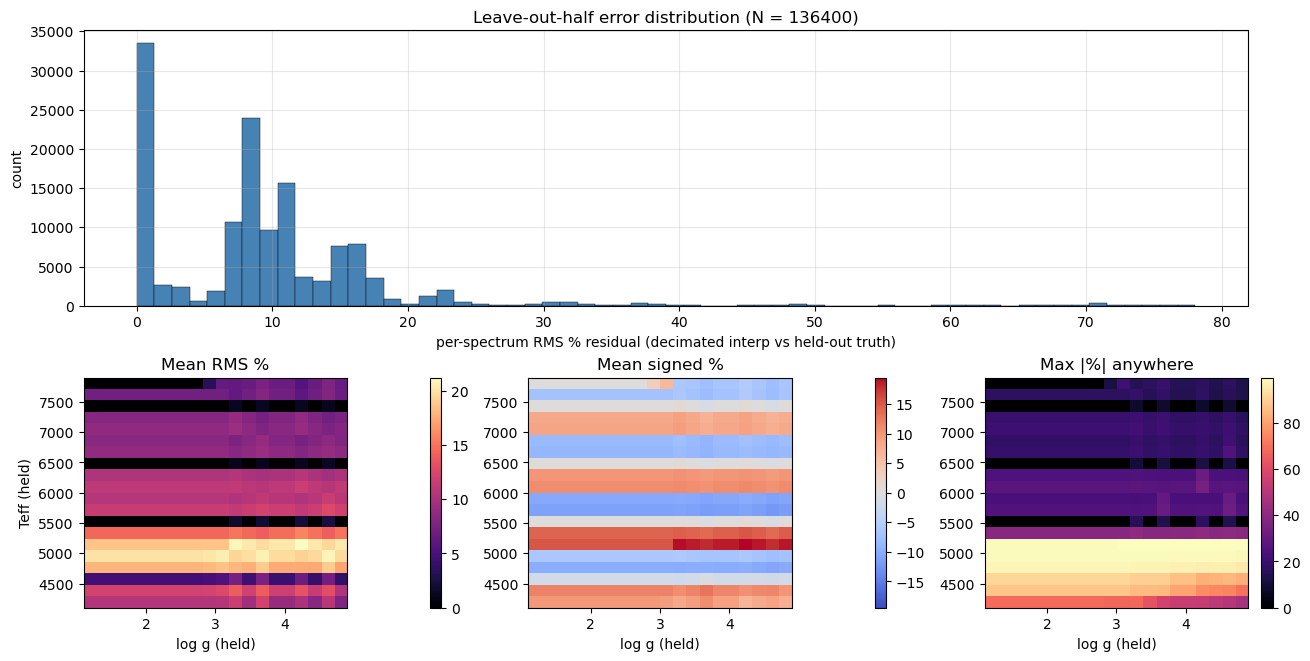

In [15]:
held_teff_col = held_df["teff"].to_numpy(dtype=np.float32)
held_logg_col = held_df["logg"].to_numpy(dtype=np.float32)


def aggregate_by_grid(values, agg):
    out = np.full((len(held_teff_vals_axis), len(held_logg_vals_axis)), np.nan)
    for i, t in enumerate(held_teff_vals_axis):
        for j, g in enumerate(held_logg_vals_axis):
            m = (held_teff_col == t) & (held_logg_col == g)
            if m.any():
                out[i, j] = float(agg(values[m]))
    return out


mean_rms_grid = aggregate_by_grid(rms_per_spec_pct, np.mean)
mean_signed_grid = aggregate_by_grid(mean_per_spec_pct, np.mean)
max_abs_grid = aggregate_by_grid(maxabs_per_spec, np.max)

fig = plt.figure(figsize=(13, 6.5), constrained_layout=True)
gs = fig.add_gridspec(2, 3, height_ratios=[1.2, 1.0])
axh = fig.add_subplot(gs[0, :])
axh.hist(rms_per_spec_pct, bins=60, color="steelblue", edgecolor="k", linewidth=0.3)
axh.set_xlabel("per-spectrum RMS % residual (decimated interp vs held-out truth)")
axh.set_ylabel("count")
axh.set_title(f"Leave-out-half error distribution (N = {len(held_queries)})")
axh.grid(alpha=0.3)

extent = [
    float(held_logg_vals_axis.min()),
    float(held_logg_vals_axis.max()),
    float(held_teff_vals_axis.min()),
    float(held_teff_vals_axis.max()),
]
kw_h = dict(extent=extent, origin="lower", aspect="auto")

ax1 = fig.add_subplot(gs[1, 0])
im1 = ax1.imshow(mean_rms_grid, **kw_h, cmap="magma")
ax1.set_xlabel("log g (held)")
ax1.set_ylabel("Teff (held)")
ax1.set_title("Mean RMS %")
plt.colorbar(im1, ax=ax1, fraction=0.046)

ax2 = fig.add_subplot(gs[1, 1])
v = float(np.nanmax(np.abs(mean_signed_grid))) or 1e-30
im2 = ax2.imshow(mean_signed_grid, **kw_h, cmap="coolwarm", vmin=-v, vmax=v)
ax2.set_xlabel("log g (held)")
ax2.set_title("Mean signed %")
plt.colorbar(im2, ax=ax2, fraction=0.046)

ax3 = fig.add_subplot(gs[1, 2])
im3 = ax3.imshow(max_abs_grid, **kw_h, cmap="magma")
ax3.set_xlabel("log g (held)")
ax3.set_title("Max |%| anywhere")
plt.colorbar(im3, ax=ax3, fraction=0.046)
plt.show()


## Mid-cell sample: corners (decimated grid) at held-out points

For the **worst / median / best** held-out rows by RMS %, list the contributing rows from `SparseGridIndex.lookup`, their weights, the manual weighted-sum at `flux[0]`, `get_weighted_batch` output, and the **truth flux[0]**.


In [16]:
for name, idx in selections.items():
    print(f"\n=== {name} ===")
    rm = held_df.iloc[idx]
    print(f"row in original index: row_idx={int(rm['row_idx'])}, "
          f"Teff={float(rm['teff']):.0f}, log g={float(rm['logg']):.3f}, "
          f"[Fe/H]={float(rm['[Fe/H]']):.2f}, mu={float(rm['mu']):.3f}")
    qv = jnp.asarray(held_queries[idx], dtype=jnp.float64)
    rows, weights = interp_dec.grid_index.lookup(qv)
    rnp = np.asarray(rows)
    wnp = np.asarray(weights)
    contrib = (rnp >= 0) & (wnp > 1e-12)
    print(f"  contributing rows: {int(contrib.sum())}")
    chk = 0.0
    for r, w in sorted(zip(rnp[contrib], wnp[contrib]), key=lambda x: -x[1]):
        chk += w * float(flux_dec_np[r, 0])
    pred0 = float(np.asarray(interp_dec.get_weighted_batch(jnp.atleast_2d(qv))["flux"][0, 0]))
    truth0 = float(held_truth[idx, 0])
    den = max(abs(pred0), abs(truth0), 1e-30)
    print(f"  manual Σ w f[0] = {chk:.4e}; get_weighted_batch[0] = {pred0:.4e}")
    print(f"  truth flux[0]   = {truth0:.4e};  Δ% = {100*(pred0-truth0)/den:+.3f}")



=== worst ===
row in original index: row_idx=159598, Teff=5100, log g=2.700, [Fe/H]=-2.50, mu=1.000
  contributing rows: 4
  manual Σ w f[0] = 1.5145e+06; get_weighted_batch[0] = 1.5145e+06
  truth flux[0]   = 2.8593e+05;  Δ% = +81.121

=== median ===
row in original index: row_idx=436809, Teff=7100, log g=1.900, [Fe/H]=0.40, mu=1.000
  contributing rows: 4
  manual Σ w f[0] = 1.1317e+07; get_weighted_batch[0] = 1.1317e+07
  truth flux[0]   = 1.0446e+07;  Δ% = +7.693

=== best ===
row in original index: row_idx=500227, Teff=7500, log g=4.100, [Fe/H]=0.40, mu=0.223
  contributing rows: 4
  manual Σ w f[0] = 6.3754e+06; get_weighted_batch[0] = 6.3754e+06
  truth flux[0]   = 6.3754e+06;  Δ% = +0.000


## 1D slices and corner-weight diagrams

Decimated-grid interpolated `flux[0]` curves along **Teff** (log g fixed) and along **log g** (Teff fixed), with kept catalogue points (orange squares) and **held-out truth** points (red circles) at the same FIXED non-thermal axes. The bottom panel is the decimated grid's stored `flux[0]` at the kept thermal vertices.

The three small panels show, for **worst / median / best** held examples, the four `(Teff, log g)` corners selected by `_compute_brackets` (size and colour scale with weight); the red star is the held-out query.


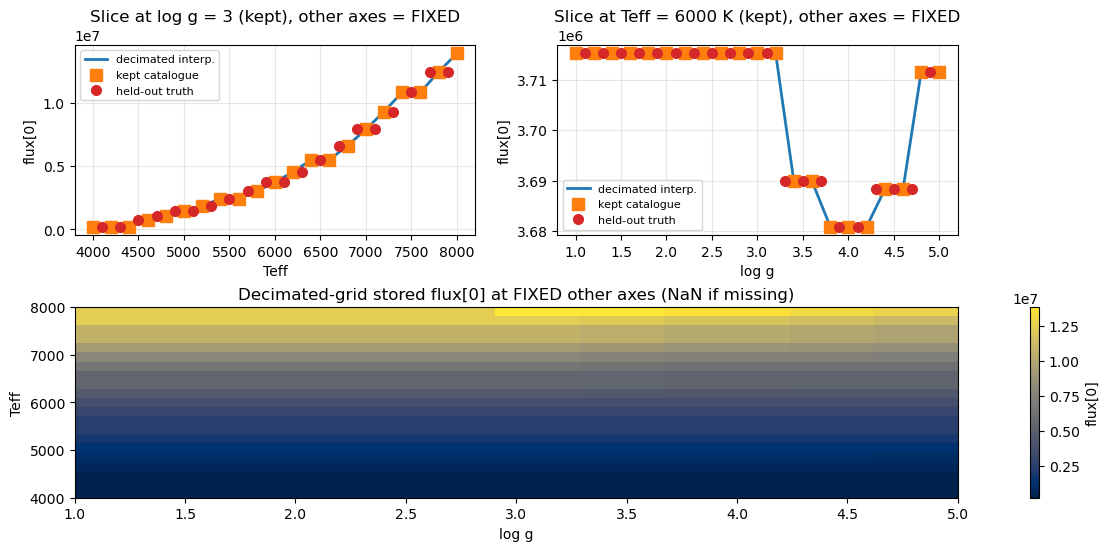

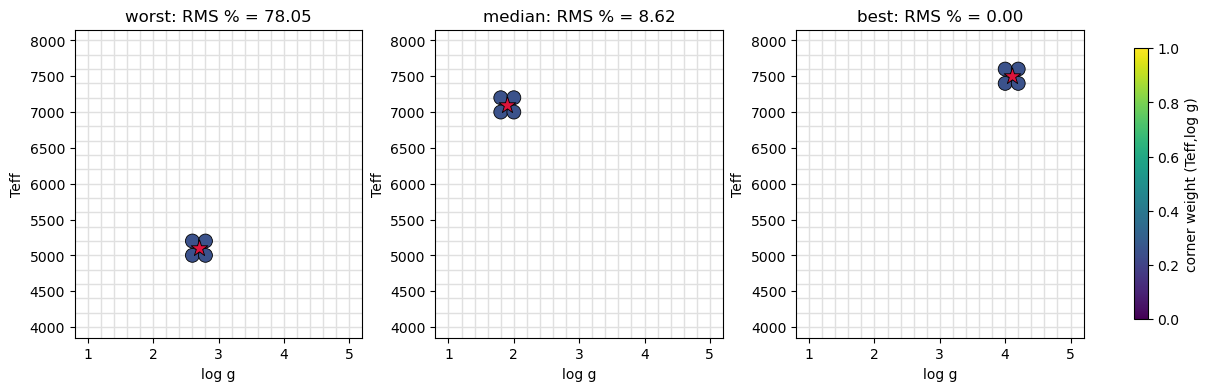

In [17]:
def df_mask_fixed_except_teff_logg(df):
    m = np.ones(len(df), dtype=bool)
    for name in COLS:
        if name in ("teff", "logg"):
            continue
        m &= np.isclose(df[name].to_numpy(dtype=np.float64), FIXED[name], rtol=0.0, atol=1e-4)
    return m


teff_lo, teff_hi = float(teff_axis.min()), float(teff_axis.max())
logg_lo, logg_hi = float(logg_axis.min()), float(logg_axis.max())
base_m_full = df_mask_fixed_except_teff_logg(_df)


def interpolated_flux_scalar_dec(teff, logg):
    qv = build_query_vec(teff, logg)
    return float(interp_dec.get_weighted_batch(jnp.atleast_2d(qv))["flux"][0, 0])


fig = plt.figure(figsize=(11, 5.4), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], width_ratios=[1.15, 1.15])

g_fix = float(keep_logg_vals[len(keep_logg_vals) // 2])
teff_line = np.linspace(teff_lo, teff_hi, 200)
f_teff = np.array([interpolated_flux_scalar_dec(float(t), g_fix) for t in teff_line])
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(teff_line, f_teff, color="C0", lw=2, label="decimated interp.")
m_kept = base_m_full & np.isclose(_df["logg"].to_numpy(), g_fix, rtol=0.0, atol=1e-4) & np.isin(
    _df["teff"].to_numpy(dtype=np.float32), keep_teff_vals
)
if m_kept.any():
    for k, (_, row) in enumerate(_df[m_kept].iterrows()):
        ax0.plot(
            float(row["teff"]), float(flux_full_np[int(row["row_idx"]), 0]),
            "s", color="C1", ms=8, zorder=3,
            label="kept catalogue" if k == 0 else None,
        )
m_held = base_m_full & np.isclose(_df["logg"].to_numpy(), g_fix, rtol=0.0, atol=1e-4) & np.isin(
    _df["teff"].to_numpy(dtype=np.float32), held_teff_vals_axis
)
if m_held.any():
    for k, (_, row) in enumerate(_df[m_held].iterrows()):
        ax0.plot(
            float(row["teff"]), float(flux_full_np[int(row["row_idx"]), 0]),
            "o", color="C3", ms=7, zorder=4,
            label="held-out truth" if k == 0 else None,
        )
ax0.set_xlabel("Teff")
ax0.set_ylabel("flux[0]")
ax0.set_title(f"Slice at log g = {g_fix:g} (kept), other axes = FIXED")
ax0.legend(loc="best", fontsize=8)
ax0.grid(alpha=0.3)

t_fix = float(keep_teff_vals[len(keep_teff_vals) // 2])
logg_line = np.linspace(logg_lo, logg_hi, 200)
f_logg = np.array([interpolated_flux_scalar_dec(t_fix, float(g)) for g in logg_line])
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(logg_line, f_logg, color="C0", lw=2, label="decimated interp.")
m_kept = base_m_full & np.isclose(_df["teff"].to_numpy(), t_fix, rtol=0.0, atol=1e-4) & np.isin(
    _df["logg"].to_numpy(dtype=np.float32), keep_logg_vals
)
if m_kept.any():
    for k, (_, row) in enumerate(_df[m_kept].iterrows()):
        ax1.plot(
            float(row["logg"]), float(flux_full_np[int(row["row_idx"]), 0]),
            "s", color="C1", ms=8, zorder=3,
            label="kept catalogue" if k == 0 else None,
        )
m_held = base_m_full & np.isclose(_df["teff"].to_numpy(), t_fix, rtol=0.0, atol=1e-4) & np.isin(
    _df["logg"].to_numpy(dtype=np.float32), held_logg_vals_axis
)
if m_held.any():
    for k, (_, row) in enumerate(_df[m_held].iterrows()):
        ax1.plot(
            float(row["logg"]), float(flux_full_np[int(row["row_idx"]), 0]),
            "o", color="C3", ms=7, zorder=4,
            label="held-out truth" if k == 0 else None,
        )
ax1.set_xlabel("log g")
ax1.set_ylabel("flux[0]")
ax1.set_title(f"Slice at Teff = {t_fix:.0f} K (kept), other axes = FIXED")
ax1.legend(loc="best", fontsize=8)
ax1.grid(alpha=0.3)

nodal = np.full((len(keep_teff_vals), len(keep_logg_vals)), np.nan, dtype=np.float64)
for i0, t in enumerate(keep_teff_vals):
    for i1, g in enumerate(keep_logg_vals):
        key = tuple(
            float(t) if nm == "teff" else float(g) if nm == "logg" else FIXED[nm] for nm in COLS
        )
        r = grid_row_idx_dec.get(key)
        if r is not None:
            nodal[i0, i1] = float(flux_dec_np[r, 0])
ax2 = fig.add_subplot(gs[1, :])
imn = ax2.imshow(
    nodal, origin="lower", aspect="auto",
    extent=[float(keep_logg_vals.min()), float(keep_logg_vals.max()),
            float(keep_teff_vals.min()), float(keep_teff_vals.max())],
    cmap="cividis",
)
ax2.set_xlabel("log g")
ax2.set_ylabel("Teff")
ax2.set_title("Decimated-grid stored flux[0] at FIXED other axes (NaN if missing)")
plt.colorbar(imn, ax=ax2, fraction=0.02, label="flux[0]")
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
mappable = None
for ax, (name, idx) in zip(axes2, selections.items()):
    for t in keep_teff_vals:
        ax.axhline(float(t), color="0.88", lw=1.0, zorder=0)
    for g in keep_logg_vals:
        ax.axvline(float(g), color="0.88", lw=1.0, zorder=0)
    rm = held_df.iloc[idx]
    qv = jnp.asarray(held_queries[idx], dtype=jnp.float64)
    _, corners = corner_points_and_weights(axes_dec, qv, COLS_DEC)
    pts = {}
    for c in corners:
        key = (c["teff"], c["logg"])
        pts[key] = pts.get(key, 0.0) + c["weight"]
    if pts:
        ts = np.array([k[0] for k in pts.keys()])
        gs2 = np.array([k[1] for k in pts.keys()])
        ws = np.array([w for w in pts.values()])
        mappable = ax.scatter(
            gs2, ts, s=np.clip(400 * ws, 30, 400), c=ws, cmap="viridis",
            edgecolors="k", linewidths=0.6, vmin=0, vmax=1, zorder=2,
        )
    ax.scatter(
        [float(rm["logg"])], [float(rm["teff"])], s=160, c="crimson", marker="*",
        edgecolors="k", linewidths=0.6, zorder=4,
    )
    ax.set_xlim(float(keep_logg_vals.min()) - 0.2, float(keep_logg_vals.max()) + 0.2)
    ax.set_ylim(float(keep_teff_vals.min()) - 150, float(keep_teff_vals.max()) + 150)
    ax.set_xlabel("log g")
    ax.set_ylabel("Teff")
    ax.set_title(f"{name}: RMS % = {rms_per_spec_pct[idx]:.2f}")
if mappable is not None:
    fig2.colorbar(mappable, ax=axes2, shrink=0.88, label="corner weight (Teff,log g)")
plt.show()


## Bar chart: corner fluxes vs reconstructed vs truth

For each of **worst / median / best**: stored `flux[0]` at every contributing decimated corner (green; label shows weight), reconstructed `flux[0]` (blue), and the **truth** `flux[0]` at the held-out query (red). A perfect interpolator would put the blue bar exactly on the red one.


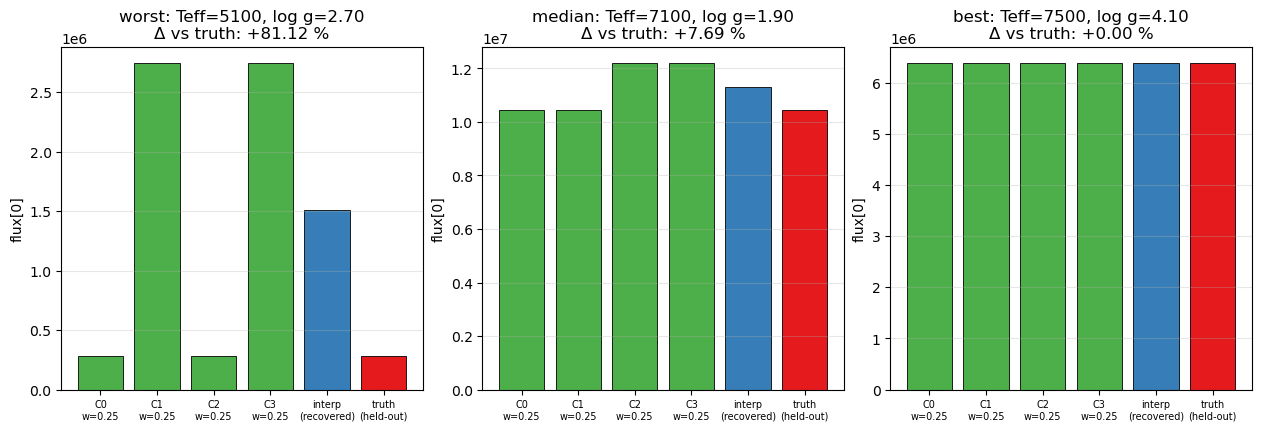

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2), constrained_layout=True)
for ax, (name, idx) in zip(axes, selections.items()):
    rm = held_df.iloc[idx]
    qv = jnp.asarray(held_queries[idx], dtype=jnp.float64)
    rows, weights = interp_dec.grid_index.lookup(qv)
    rnp = np.asarray(rows)
    wnp = np.asarray(weights)
    contrib = (rnp >= 0) & (wnp > 1e-12)
    items = sorted(zip(rnp[contrib], wnp[contrib]), key=lambda x: -x[1])
    labels, vals, colors = [], [], []
    nshow = min(len(items), 12)
    for k, (r, w) in enumerate(items[:nshow]):
        labels.append(f"C{k}\nw={w:.2f}")
        vals.append(float(flux_dec_np[int(r), 0]))
        colors.append("#4daf4a")
    fi = float(held_pred[idx, 0])
    ft = float(held_truth[idx, 0])
    labels += ["interp\n(recovered)", "truth\n(held-out)"]
    vals += [fi, ft]
    colors += ["#377eb8", "#e41a1c"]
    x = np.arange(len(vals))
    ax.bar(x, vals, color=colors, edgecolor="k", linewidth=0.6)
    ax.set_xticks(x, labels, fontsize=7)
    ax.set_ylabel("flux[0]")
    den = max(abs(fi), abs(ft), 1e-30)
    ax.set_title(
        f"{name}: Teff={float(rm['teff']):.0f}, log g={float(rm['logg']):.2f}\n"
        f"Δ vs truth: {100*(fi-ft)/den:+.2f} %"
    )
    ax.grid(axis="y", alpha=0.3)
    if len(items) > nshow:
        ax.text(0.02, 0.95, f"+{len(items)-nshow} more corners",
                transform=ax.transAxes, va="top", fontsize=7)
plt.show()


## Spectrum overlay: reconstructed vs held-out truth

For **worst / median / best**: contributing decimated-grid neighbour spectra (faint grey, opacity scales with lookup weight), reconstructed spectrum (blue), and the **held-out truth** spectrum (orange dashed). The right column is the per-pixel residual `reconstructed − truth` in `flux` units.


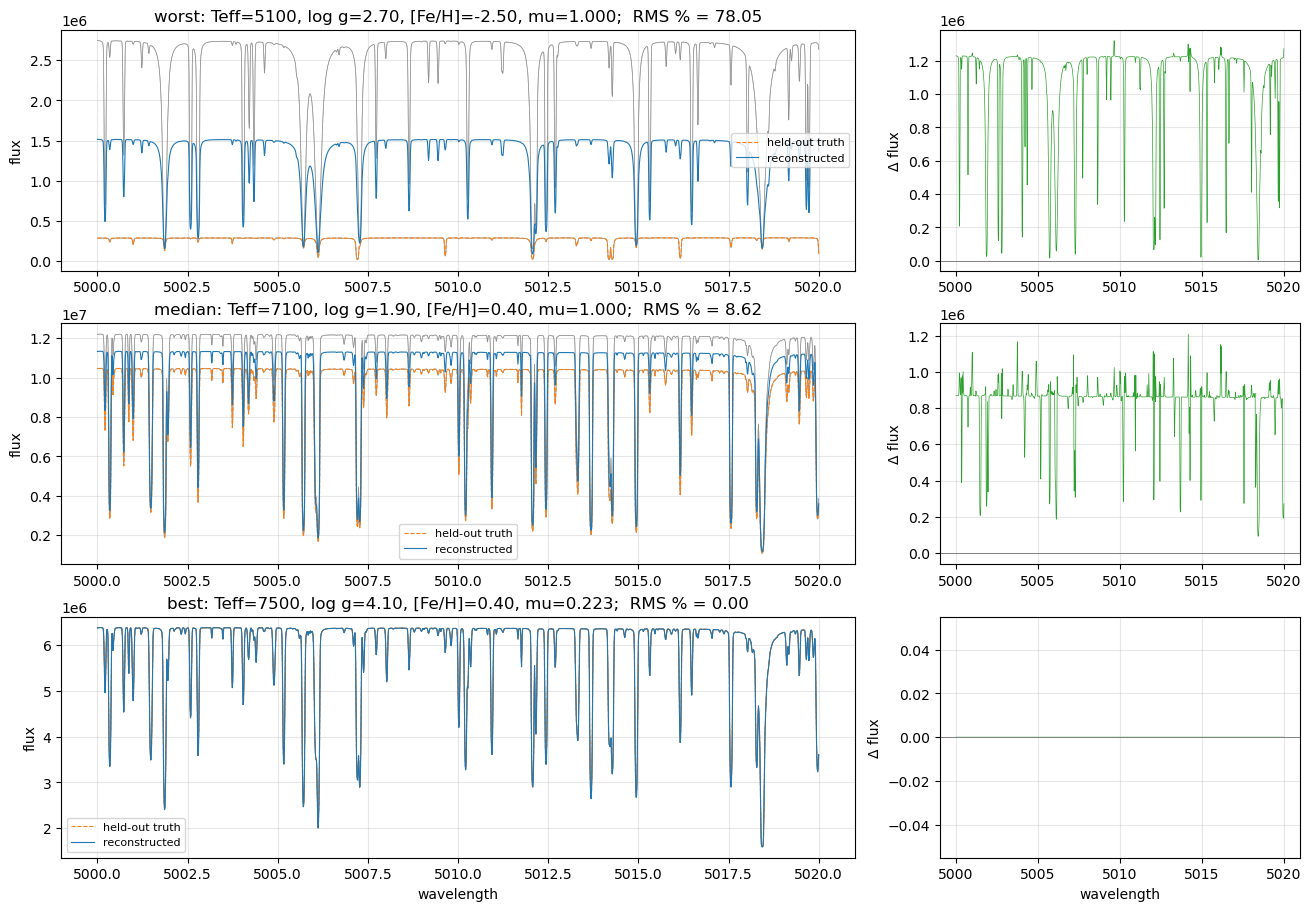

In [12]:
fig, axes = plt.subplots(
    3, 2, figsize=(13, 9),
    gridspec_kw={"height_ratios": [1, 1, 1], "width_ratios": [2.2, 1]},
    constrained_layout=True,
)
for row_axes, (name, idx) in zip(axes, selections.items()):
    ax_spec, ax_res = row_axes
    rm = held_df.iloc[idx]
    qv = jnp.asarray(held_queries[idx], dtype=jnp.float64)
    rows, weights = interp_dec.grid_index.lookup(qv)
    rnp = np.asarray(rows)
    wnp = np.asarray(weights)
    contrib = (rnp >= 0) & (wnp > 1e-12)
    wmax = float(wnp[contrib].max()) if contrib.any() else 1.0
    for r, w in zip(rnp[contrib], wnp[contrib]):
        ax_spec.plot(
            wave_np, flux_dec_np[int(r)], lw=0.5, color="0.55",
            alpha=min(0.22 + 0.55 * (w / wmax), 0.9),
        )
    ax_spec.plot(wave_np, held_truth[idx], lw=0.8, ls="--", color="C1",
                 label="held-out truth", zorder=5)
    ax_spec.plot(wave_np, held_pred[idx], lw=0.8, color="C0",
                 label="reconstructed", zorder=5)
    ax_spec.set_ylabel("flux")
    ax_spec.set_title(
        f"{name}: Teff={float(rm['teff']):.0f}, log g={float(rm['logg']):.2f}, "
        f"[Fe/H]={float(rm['[Fe/H]']):.2f}, mu={float(rm['mu']):.3f};  "
        f"RMS % = {rms_per_spec_pct[idx]:.2f}"
    )
    ax_spec.legend(loc="best", fontsize=8)
    ax_spec.grid(alpha=0.3)

    ax_res.plot(wave_np, held_pred[idx] - held_truth[idx], lw=0.5, color="C2")
    ax_res.axhline(0.0, color="gray", lw=0.7)
    ax_res.set_ylabel("Δ flux")
    ax_res.grid(alpha=0.3)
axes[-1, 0].set_xlabel("wavelength")
axes[-1, 1].set_xlabel("wavelength")
plt.show()


## Cleanup

Remove the temporary decimated zarr. The repo's `data/fe_nlte_new.zarr` is left untouched on disk.


In [13]:
shutil.rmtree(tmp_dir, ignore_errors=True)
print("Removed", tmp_dir)


Removed /jobfs/168654617.gadi-pbs/spice_leave_out_half_69z8wfr1
